<a href="https://colab.research.google.com/github/Elchegue64/TAREAS-SSF/blob/T11/T11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Estadístico basado en SciPy Lectures
Este notebook replica los análisis principales usando el dataset proporcionado.

## 1. Carga de datos

In [3]:
import pandas as pd
df = pd.read_excel('/content/S1_Dataset.xlsx')
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Sex,Age,BADS-SF,BADS-SF_Activation,BADS-SF_Avoidance,CES-D,WHOQOL-26_Mean total score,WHOQOL-26_Phisical health,WHOQOL-26_Psychological health,WHOQOL-26_Social relationships,WHOQOL-26_Environment,WHOQOL-26_Overall QOL
0,2,20,37,22,3,1,4.500000,4.833333,4.142857,5.000000,4.375,4.5
1,2,18,33,17,2,2,3.307692,3.166667,3.571429,2.666667,3.250,4.0
2,1,19,30,20,8,2,3.500000,3.833333,3.285714,3.666667,3.250,4.0
3,1,19,23,11,6,3,3.346154,3.500000,3.571429,4.000000,2.750,3.5
4,2,18,35,19,2,3,4.461538,4.500000,4.857143,5.000000,3.875,4.5


## 2. Estadísticos descriptivos

In [4]:
df.describe()

,Sex,Age,BADS-SF,BADS-SF_Activation,BADS-SF_Avoidance,CES-D,WHOQOL-26_Mean total score,WHOQOL-26_Phisical health,WHOQOL-26_Psychological health,WHOQOL-26_Social relationships,WHOQOL-26_Environment,WHOQOL-26_Overall QOL
count,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,1.579186,19.366516,23.506787,13.018100,7.511312,15.407240,3.306300,3.152338,3.446671,3.321267,3.311086,3.235294
std,0.494811,1.736392,8.086813,5.929099,4.019963,8.046837,0.562881,0.739349,0.616897,0.772543,0.627111,0.830566
min,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.615385,1.000000,1.714286,1.000000,1.000000,1.000000
25%,1.000000,19.000000,18.000000,9.000000,5.000000,10.000000,3.000000,2.666667,3.000000,3.000000,3.000000,2.500000
50%,2.000000,19.000000,23.000000,13.000000,7.000000,14.000000,3.307692,3.166667,3.428571,3.333333,3.375000,3.000000
75%,2.000000,20.000000,29.000000,17.000000,10.000000,19.000000,3.653846,3.666667,3.857143,4.000000,3.625000,4.000000
max,2.000000,25.000000,46.000000,30.000000,18.000000,49.000000,4.884615,5.000000,4.857143,5.000000,5.000000,5.000000


## 3. Histograma de CES-D

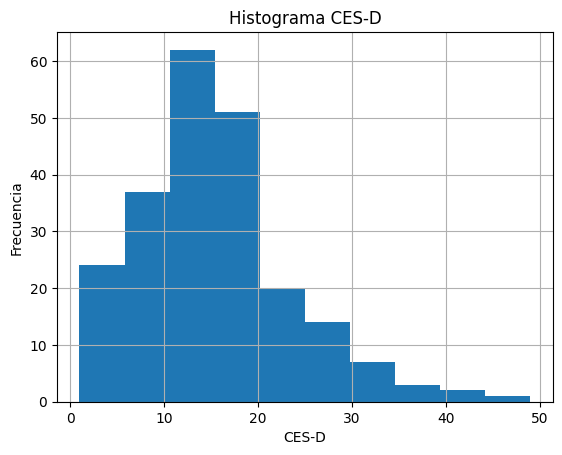

In [5]:
import matplotlib.pyplot as plt
df['CES-D'].hist()
plt.xlabel('CES-D')
plt.ylabel('Frecuencia')
plt.title('Histograma CES-D')
plt.show()

## 4. Correlaciones

In [6]:
df.corr()

,Sex,Age,BADS-SF,BADS-SF_Activation,BADS-SF_Avoidance,CES-D,WHOQOL-26_Mean total score,WHOQOL-26_Phisical health,WHOQOL-26_Psychological health,WHOQOL-26_Social relationships,WHOQOL-26_Environment,WHOQOL-26_Overall QOL
Sex,1.000000,0.217362,0.072850,0.145148,0.067531,-0.088048,0.046847,0.099408,0.127176,-0.108471,-0.024815,0.042940
Age,0.217362,1.000000,0.019406,0.061164,0.051173,-0.051395,0.055259,0.044827,0.019846,0.077859,0.067006,0.004542
BADS-SF,0.072850,0.019406,1.000000,0.880032,-0.713693,-0.552986,0.593620,0.650971,0.511778,0.392175,0.363593,0.515780
BADS-SF_Activation,0.145148,0.061164,0.880032,1.000000,-0.295414,-0.396294,0.546006,0.579689,0.442321,0.383757,0.358195,0.495258
BADS-SF_Avoidance,0.067531,0.051173,-0.713693,-0.295414,1.000000,0.527921,-0.388852,-0.454543,-0.377140,-0.222916,-0.203120,-0.307113
CES-D,-0.088048,-0.051395,-0.552986,-0.396294,0.527921,1.000000,-0.580423,-0.635695,-0.487452,-0.423051,-0.367619,-0.448311
WHOQOL-26_Mean total score,0.046847,0.055259,0.593620,0.546006,-0.388852,-0.580423,1.000000,0.863298,0.855327,0.742387,0.839231,0.710835
WHOQOL-26_Phisical health,0.099408,0.044827,0.650971,0.579689,-0.454543,-0.635695,0.863298,1.000000,0.680386,0.602737,0.573361,0.593981
WHOQOL-26_Psychological health,0.127176,0.019846,0.511778,0.442321,-0.377140,-0.487452,0.855327,0.680386,1.000000,0.539111,0.598453,0.559418
WHOQOL-26_Social relationships,-0.108471,0.077859,0.392175,0.383757,-0.222916,-0.423051,0.742387,0.602737,0.539111,1.000000,0.550784,0.470810


## 5. Regresión lineal

In [7]:
import statsmodels.api as sm
X = df[['BADS-SF_Activation','BADS-SF_Avoidance']]
y = df['CES-D']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  CES-D   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     56.65
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.54e-20
Time:                        22:33:39   Log-Likelihood:                -727.68
No. Observations:                 221   AIC:                             1461.
Df Residuals:                     218   BIC:                             1472.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 13.2915      1.579      8.417      0.000      10.179      16.404
BADS-SF_Activation    -0.3574      0.078     -4.579      0.000      -0.511      -0.204
BADS-SF_Avoidance      0.9010      0.115      7.828      0.000       0.674       1.128
==============================================================================
Omnibus:                       31.441   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.646
Skew:                           0.815   Prob(JB):                     2.73e-11
Kurtosis:                       4.620   Cond. No.                         56.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""